In [9]:
import tensorflow as tf
import pandas as pd
import numpy as np
import cv2
import os

import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
import albumentations as A
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import EfficientNetB3, EfficientNetB0, ResNet50
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATASET_DIR = "/content/drive/MyDrive/mashrooms-vision/"
IMG_DIR = DATASET_DIR + "dataset/dataset/"

train_df = pd.read_csv(DATASET_DIR + "train.csv")
test_df = pd.read_csv(DATASET_DIR + "test.csv")

In [11]:
train_df.head()

,Image,Mushroom
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [17]:
train_df.shape

(2365, 2)

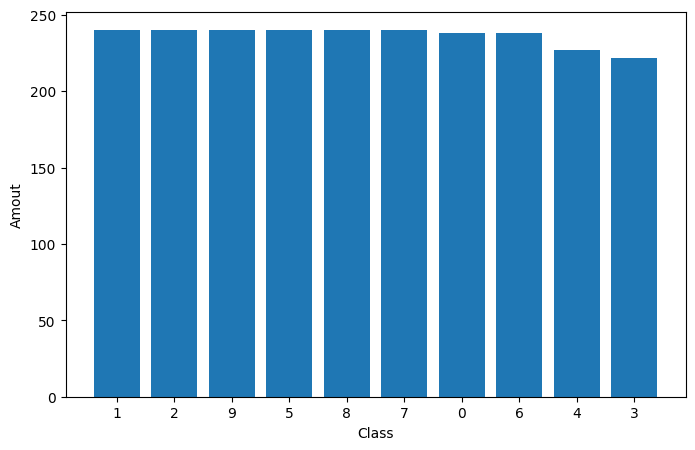

In [8]:
class_counts = train_df['Mushroom'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(class_counts.index.astype(str), class_counts.values)

plt.xlabel("Class")
plt.ylabel("Amout")
plt.xticks(rotation=0)
plt.show()

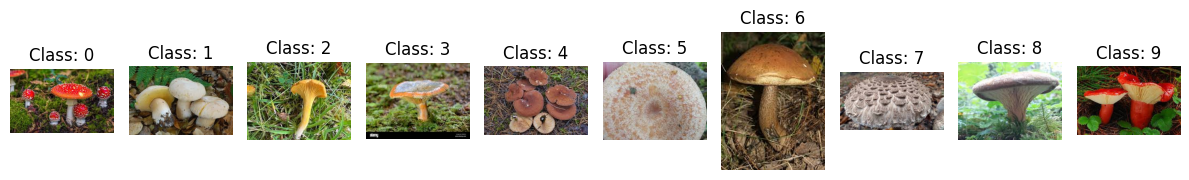

In [15]:
classes = train_df['Mushroom'].unique()

plt.figure(figsize=(12, 6))

for i, cls in enumerate(classes):
    sample = train_df[train_df['Mushroom'] == cls].iloc[4]
    img_name = f"{sample['Image']:05d}.jpg"

    img_path = os.path.join(IMG_DIR, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.title(f"Class: {cls}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [18]:
bad = []
for file in os.listdir(IMG_DIR):
    img = cv2.imread(os.path.join(IMG_DIR, file))
    if img is None:
        bad.append(file)
bad

[]

##Data splitting for model training

In [ ]:
train_unsampled, val = train_test_split(train_df, stratify=train_df['Mushroom'], test_size=0.2, random_state=42)
val, test = train_test_split(val, stratify=val['Mushroom'], test_size=0.25, random_state=42)

In [ ]:
def pathify(df):
    df['Image'] = df['Image'].apply(lambda x: IMG_DIR + str(x).zfill(5) + ".jpg")
    return df

train_unsampled = pathify(train_unsampled)
val = pathify(val)
test = pathify(test)

In [ ]:
train_unsampled

,Image,Mushroom
370,/content/drive/MyDrive/mashrooms-vision/datase...,1
134,/content/drive/MyDrive/mashrooms-vision/datase...,0
904,/content/drive/MyDrive/mashrooms-vision/datase...,3
380,/content/drive/MyDrive/mashrooms-vision/datase...,1
2230,/content/drive/MyDrive/mashrooms-vision/datase...,9
...,...,...
1351,/content/drive/MyDrive/mashrooms-vision/datase...,5
1004,/content/drive/MyDrive/mashrooms-vision/datase...,4
223,/content/drive/MyDrive/mashrooms-vision/datase...,0
886,/content/drive/MyDrive/mashrooms-vision/datase...,3


In [ ]:
train_unsampled['Mushroom'].unique()

array([1, 0, 3, 9, 7, 2, 5, 8, 6, 4])

In [ ]:
train_unsampled['Mushroom'].value_counts()

,count
Mushroom,
1,192
9,192
8,192
7,192
2,192
5,192
0,190
6,190
4,182


##Dataset preparation

In [ ]:
BATCH_SIZE = 32
IMAGE_SIZE = (224,224)

In [ ]:
def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    #image = image / 255.0 #only for b0
    return image, label

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices((train_unsampled['Image'].values, train_unsampled['Mushroom'].values))
train_ds = train_ds.shuffle(len(train_unsampled)).map(load_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val['Image'].values, val['Mushroom'].values))
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test['Image'].values, test['Mushroom'].values))
test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

##Dataset inspection and sanity check


In [ ]:
for x, y in train_ds.take(1):
    print("Batch images:", x.shape)
    print("Batch labels:", y.numpy())

Batch images: (32, 224, 224, 3)
Batch labels: [6 9 1 1 8 5 1 4 1 5 5 8 1 9 7 3 2 3 8 9 5 5 9 3 6 0 8 0 7 3 8 2]


In [ ]:
num_classes = train_unsampled['Mushroom'].nunique()
print("Number of classes:", num_classes)

print("Train classes:", train_unsampled['Mushroom'].unique())
print("Val classes:", val['Mushroom'].unique())
print("Test classes:", test['Mushroom'].unique())

print("Train distribution:\n", train_unsampled['Mushroom'].value_counts())
print("Val distribution:\n", val['Mushroom'].value_counts())
print("Test distribution:\n", test['Mushroom'].value_counts())

Number of classes: 10
Train classes: [1 0 3 9 7 2 5 8 6 4]
Val classes: [5 2 1 9 0 8 7 6 3 4]
Test classes: [6 2 8 5 9 4 7 3 0 1]
Train distribution:
 Mushroom
1    192
9    192
8    192
7    192
2    192
5    192
0    190
6    190
4    182
3    178
Name: count, dtype: int64
Val distribution:
 Mushroom
5    36
2    36
1    36
9    36
0    36
8    36
7    36
6    36
3    33
4    33
Name: count, dtype: int64
Test distribution:
 Mushroom
6    12
2    12
8    12
5    12
9    12
4    12
7    12
0    12
1    12
3    11
Name: count, dtype: int64


##CNN models
####EfficientNetB0


In [ ]:
data_augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

base_model5 = tf.keras.applications.EfficientNetB0(
    include_top=False,
    input_shape=(224,224,3),
    weights="imagenet"
)


base_model5.trainable = True
for layer in base_model5.layers[:40]:
    layer.trainable = False

model5 = tf.keras.Sequential([
    data_augment,
    base_model5,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

model5.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True)
]

history = model5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

test_loss, test_acc = model5.evaluate(test_ds)
print("Test accuracy:", test_acc)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 56s 296ms/step - accuracy: 0.1351 - loss: 3.0284 - val_accuracy: 0.1017 - val_loss: 2.3398 - learning_rate: 3.0000e-04
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 252ms/step - accuracy: 0.2946 - loss: 2.3451 - val_accuracy: 0.1299 - val_loss: 2.3227 - learning_rate: 3.0000e-04
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 247ms/step - accuracy: 0.3295 - loss: 2.0936 - val_accuracy: 0.1186 - val_loss: 2.3484 - learning_rate: 3.0000e-04
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 263ms/step - accuracy: 0.4188 - loss: 1.7522 - val_accuracy: 0.1186 - val_loss: 2.3930 - learning_rate: 3.0000e-04
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 248ms/step - accuracy: 0.4520 - loss: 1.6459 - val_accuracy: 0.1356 - val_loss: 2.5468 - learning_rate: 3.0000e-04
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 248ms/step - accuracy: 0.5369 - loss: 1.3958 - val_accuracy: 0.2062 - val_loss: 2.4327 - learning_rate: 9.0000e-05
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 247ms/step - acc

####EfficientNetB3

In [ ]:
data_augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.Lambda(preprocess_input),
])

base_model = EfficientNetB3(
    include_top=False,
    input_shape=(224,224,3),
    weights="imagenet"
)
base_model.trainable = False

model_b3 = tf.keras.Sequential([
    data_augment,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

model_b3.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


callbacks = [
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, verbose=1),
    EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_efficientnetb3.keras", save_best_only=True, verbose=1)
]

history = model_b3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

base_model.trainable = True
for layer in base_model.layers[:-100]:
    layer.trainable = False

model_b3.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = model_b3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

test_loss, test_acc = model_b3.evaluate(test_ds)
print("Test accuracy:", test_acc)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2963 - loss: 2.5177
Epoch 1: val_loss improved from inf to 1.55125, saving model to best_efficientnetb3.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 397s 6s/step - accuracy: 0.2981 - loss: 2.5091 - val_accuracy: 0.4689 - val_loss: 1.5513 - learning_rate: 0.0010
Epoch 2/10
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.5981 - loss: 1.2275
Epoch 2: val_loss improved from 1.55125 to 1.04037, saving model to best_efficientnetb3.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 190ms/step - accuracy: 0.5987 - loss: 1.2274 - val_accuracy: 0.7316 - val_loss: 1.0404 - learning_rate: 0.0010
Epoch 3/10
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.6830 - loss: 1.0376
Epoch 3: val_loss improved from 1.04037 to 0.87559, saving model to best_efficientnetb3.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 188ms/step - accuracy: 0.6828 - loss: 1.0367 - val_accuracy: 0.7458 - val_loss: 0.8756 - learning_rate:

In [ ]:
model_b3.save("/content/drive/MyDrive/mashrooms-vision/model-b3-100.keras")

####ResNet

In [ ]:
data_augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

base_model = ResNet50(
    include_top=False,
    input_shape=(224,224,3),
    weights="imagenet"
)

base_model.trainable = True
for layer in base_model.layers[:-100]:
    layer.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))
x = data_augment(inputs)
x = tf.keras.applications.resnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation="softmax")(x)

model_resnet = tf.keras.Model(inputs, outputs, name="ResNet50-Mushroom")


model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, verbose=1)
early_stop = EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint("best_resnet.keras", save_best_only=True, verbose=1)

callbacks = [reduce_lr, early_stop, checkpoint]

history = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

test_loss, test_acc = model_resnet.evaluate(test_ds)
print("Test accuracy:", test_acc)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.1783 - loss: 2.9781
Epoch 1: val_loss improved from inf to 1.42685, saving model to best_resnet.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 53s 450ms/step - accuracy: 0.1796 - loss: 2.9716 - val_accuracy: 0.5565 - val_loss: 1.4269 - learning_rate: 1.0000e-04
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.4623 - loss: 1.6864
Epoch 2: val_loss improved from 1.42685 to 0.91639, saving model to best_resnet.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 409ms/step - accuracy: 0.4634 - loss: 1.6838 - val_accuracy: 0.7175 - val_loss: 0.9164 - learning_rate: 1.0000e-04
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.6309 - loss: 1.1664
Epoch 3: val_loss improved from 0.91639 to 0.83825, saving model to best_resnet.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 407ms/step - accuracy: 0.6312 - loss: 1.1657 - val_accuracy: 0.7655 - val_loss: 0.8382 - learning_rate: 1.0000e-04
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/ste

In [ ]:
model_resnet.save("/content/drive/MyDrive/mashrooms-vision/model-res.keras")